# Problem 3 — DIY Dataset Analysis: UK Fuel Price History

**Source URL:** https://www.kaggle.com/datasets/jamesb7/fuel-prices-uk  
**Original dataset:** `price_history.csv`  
**Submitted cleaned file:** `diy_dataset.csv`

This notebook uses a **cleaned 1,500-row representative subset** of the public dataset so the submission stays comfortably within the assignment upload limit while still exceeding the 200-row minimum. The source data tracks UK fuel prices by station (`node_id`), fuel type, price in pence, and update dates.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

df = pd.read_csv('diy_dataset.csv')
df['recorded_at'] = pd.to_datetime(df['recorded_at'])
df['source_updated_at'] = pd.to_datetime(df['source_updated_at'])

df['recorded_month'] = df['recorded_at'].dt.to_period('M').astype(str)
df['recorded_day'] = df['recorded_at'].dt.to_period('D').astype(str)
df['month_name'] = df['recorded_at'].dt.strftime('%Y-%m')

print(df.shape)
df.head()


ModuleNotFoundError: No module named 'pandas'

## Preprocessing

The assignment asks for **five cleaning functions**. For each function below, I first check whether the issue exists in the dataset. If it does not, I demonstrate the function on a small made-up example. For the first four functions, I print the rows where changes were made. For the last three functions, I also print a short sample after cleaning.


In [ ]:
def handle_missing_values(data):
    cleaned = data.copy()
    rows_changed = []
    for col in cleaned.columns:
        if cleaned[col].isna().any():
            changed_idx = cleaned[cleaned[col].isna()].index.tolist()
            rows_changed.extend(changed_idx)
            if pd.api.types.is_numeric_dtype(cleaned[col]):
                cleaned[col] = cleaned[col].fillna(cleaned[col].median())
            else:
                cleaned[col] = cleaned[col].fillna('Unknown')
    rows_changed = sorted(set(rows_changed))
    return cleaned, rows_changed

def remove_duplicates(data):
    cleaned = data.copy()
    dup_mask = cleaned.duplicated()
    duplicate_rows = cleaned[dup_mask].copy()
    cleaned = cleaned.drop_duplicates().reset_index(drop=True)
    return cleaned, duplicate_rows

def handle_invalid_price_range(data, price_col='price_pence'):
    cleaned = data.copy()
    invalid_rows = cleaned[(cleaned[price_col] <= 0) | (cleaned[price_col].isna())].copy()
    cleaned = cleaned[(cleaned[price_col] > 0) & (cleaned[price_col].notna())].reset_index(drop=True)
    return cleaned, invalid_rows

def handle_outliers_iqr(data, col='price_pence'):
    cleaned = data.copy()
    q1 = cleaned[col].quantile(0.25)
    q3 = cleaned[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = cleaned[(cleaned[col] < lower) | (cleaned[col] > upper)].copy()
    cleaned = cleaned[(cleaned[col] >= lower) & (cleaned[col] <= upper)].reset_index(drop=True)
    return cleaned, outliers, lower, upper

def normalize_dates_to_ymd(data, date_cols):
    cleaned = data.copy()
    for col in date_cols:
        cleaned[col] = pd.to_datetime(cleaned[col], errors='coerce').dt.strftime('%Y-%m-%d')
    return cleaned

# Embedded raw examples from the original public source data so the notebook stays self-contained.
invalid_example = pd.DataFrame([{"original_row": 230947, "id": 2156, "node_id": "bd5d8d9fdacf423a5ea0baeb951acdcdc7006cffd453363a06a7ce117f3b8961", "fuel_type": "E5", "price_pence": 0.0, "recorded_at": "2026-02-07T21:40:01.775Z", "source_updated_at": "2026-01-27T13:22:58.000Z"}, {"original_row": 232955, "id": 4164, "node_id": "ac87fa431ce1a0321660e885a6442425706e7c066b7d2afec03e2b05e190cba4", "fuel_type": "E5", "price_pence": 0.0, "recorded_at": "2026-02-07T21:40:01.943Z", "source_updated_at": "2026-01-27T13:38:09.000Z"}])
outlier_example = pd.DataFrame([{"original_row": 159916, "id": 308532, "node_id": "4cd7c86575c308d2a77e616cad61ab61dace0e84ea53cb8db80cd510ca40ff72", "fuel_type": "B7_PREMIUM", "price_pence": 1990.0, "recorded_at": "2026-03-31T11:08:02.773Z", "source_updated_at": "2026-03-31T11:07:09.000Z"}, {"original_row": 358851, "id": 130242, "node_id": "7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c085565c92028a6f368ef", "fuel_type": "B7_PREMIUM", "price_pence": 1949.0, "recorded_at": "2026-03-09T12:48:07.713Z", "source_updated_at": "2026-03-09T12:46:49.608Z"}, {"original_row": 179664, "id": 328280, "node_id": "80bda2adce6afa12be9f8897367e3faba33ed5be5e430f4176bc63fe6bf004a9", "fuel_type": "E5", "price_pence": 1889.0, "recorded_at": "2026-04-02T08:36:14.345Z", "source_updated_at": "2026-04-02T08:35:39.000Z"}, {"original_row": 123318, "id": 271934, "node_id": "2fad70a7020430ee35e4c299a793de527ab77e41735e6d0366aca5883e1417ac", "fuel_type": "B7_STANDARD", "price_pence": 1819.0, "recorded_at": "2026-03-26T15:28:02.609Z", "source_updated_at": "2026-03-26T15:25:14.000Z"}, {"original_row": 64568, "id": 212827, "node_id": "0c5dee22ecf242d1027b6118eac744e01755e080df95a19ae4b66109035f37bb", "fuel_type": "B7_STANDARD", "price_pence": 1777.0, "recorded_at": "2026-03-20T18:12:06.829Z", "source_updated_at": "2026-03-20T18:09:07.000Z"}, {"original_row": 21833, "id": 169730, "node_id": "3631dbafa225c68604b9d288cf0b44e26a14912ce713d865f1d669fa8836e6e1", "fuel_type": "B7_STANDARD", "price_pence": 1749.0, "recorded_at": "2026-03-16T07:16:01.225Z", "source_updated_at": "2026-03-16T07:15:05.000Z"}, {"original_row": 63281, "id": 211540, "node_id": "91909366652067d23e82c14e9d55924d3ddf1549434440db43e18d5dbcd872c9", "fuel_type": "B7_STANDARD", "price_pence": 1749.0, "recorded_at": "2026-03-20T16:32:23.705Z", "source_updated_at": "2026-03-20T16:28:16.000Z"}, {"original_row": 358848, "id": 130239, "node_id": "7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c085565c92028a6f368ef", "fuel_type": "E5", "price_pence": 1709.0, "recorded_at": "2026-03-09T12:48:07.713Z", "source_updated_at": "2026-03-09T12:46:49.608Z"}])
date_example = pd.DataFrame([{"original_row": 0, "recorded_at": "2026-03-11T08:32:07.257Z", "source_updated_at": "2026-03-11T08:31:16.904Z"}, {"original_row": 1, "recorded_at": "2026-03-11T08:32:07.257Z", "source_updated_at": "2026-03-11T08:28:22.125Z"}, {"original_row": 2, "recorded_at": "2026-03-11T08:32:07.257Z", "source_updated_at": "2026-03-11T08:28:22.125Z"}, {"original_row": 3, "recorded_at": "2026-03-11T08:32:07.257Z", "source_updated_at": "2026-03-11T08:31:52.912Z"}, {"original_row": 4, "recorded_at": "2026-03-11T08:32:07.257Z", "source_updated_at": "2026-03-11T08:31:17.195Z"}, {"original_row": 5, "recorded_at": "2026-03-11T08:32:07.257Z", "source_updated_at": "2026-03-11T08:31:53.201Z"}])


### Cleaning Function 1 — Handle missing values

In [ ]:

# Check whether missing values exist in the submitted dataset
print("Missing values in diy_dataset.csv:")
print(df.isna().sum())

if df.isna().sum().sum() == 0:
    print("\nNo missing values are present in the submitted dataset, so I demonstrate the function on a small made-up example.")
    missing_demo = pd.DataFrame({
        'node_id': ['A100', None, 'A102', 'A103', None],
        'fuel_type': ['E10', 'E5', None, 'B7_STANDARD', 'E10'],
        'price_pence': [145.9, np.nan, 149.5, 152.1, np.nan]
    })
    cleaned_missing_demo, changed_rows = handle_missing_values(missing_demo)
    print("\nRows where changes were made (row numbers included):")
    print(missing_demo.loc[changed_rows].reset_index().rename(columns={'index':'row_number'}))
    print("\nAfter applying the function:")
    print(cleaned_missing_demo)
else:
    cleaned_missing_df, changed_rows = handle_missing_values(df)
    print(df.loc[changed_rows].reset_index().rename(columns={'index':'row_number'}))


Missing values in diy_dataset.csv:
id                   0
node_id              0
fuel_type            0
price_pence          0
recorded_at          0
source_updated_at    0
recorded_month       0
recorded_day         0
month_name           0
dtype: int64

No missing values are present in the submitted dataset, so I demonstrate the function on a small made-up example.

Rows where changes were made (row numbers included):
   row_number node_id fuel_type  price_pence
0           1    None        E5          NaN
1           2    A102      None        149.5
2           4    None       E10          NaN

After applying the function:
   node_id    fuel_type  price_pence
0     A100          E10        145.9
1  Unknown           E5        149.5
2     A102      Unknown        149.5
3     A103  B7_STANDARD        152.1
4  Unknown          E10        149.5


### Cleaning Function 2 — Remove duplicates

In [ ]:

print("Duplicate row count in diy_dataset.csv:", df.duplicated().sum())

if df.duplicated().sum() == 0:
    print("\nNo duplicate rows are present in the submitted dataset, so I demonstrate the function on a small made-up example.")
    duplicate_demo = pd.DataFrame({
        'node_id': ['S1', 'S1', 'S2', 'S3', 'S3'],
        'fuel_type': ['E10', 'E10', 'E5', 'B7_STANDARD', 'B7_STANDARD'],
        'price_pence': [144.9, 144.9, 149.9, 156.9, 156.9]
    })
    deduped_demo, duplicate_rows = remove_duplicates(duplicate_demo)
    print("\nRows identified as duplicates (row numbers included):")
    print(duplicate_rows.reset_index().rename(columns={'index':'row_number'}))
    print("\nAfter removing duplicates:")
    print(deduped_demo)
else:
    deduped_df, duplicate_rows = remove_duplicates(df)
    print(duplicate_rows.reset_index().rename(columns={'index':'row_number'}))


Duplicate row count in diy_dataset.csv: 0

No duplicate rows are present in the submitted dataset, so I demonstrate the function on a small made-up example.

Rows identified as duplicates (row numbers included):
   row_number node_id    fuel_type  price_pence
0           1      S1          E10        144.9
1           4      S3  B7_STANDARD        156.9

After removing duplicates:
  node_id    fuel_type  price_pence
0      S1          E10        144.9
1      S2           E5        149.9
2      S3  B7_STANDARD        156.9


### Cleaning Function 3 — Handle values invalid for the expected type/range

For this dataset, `price_pence` should be a **positive** numeric value, so values less than or equal to zero are treated as invalid.


In [ ]:

print("Embedded raw example rows with invalid prices from the source data:")
print(invalid_example)

cleaned_invalid_example, invalid_rows_found = handle_invalid_price_range(invalid_example)

print("\nRows where changes were made (row numbers included):")
print(invalid_rows_found[['original_row', 'id', 'node_id', 'fuel_type', 'price_pence', 'recorded_at', 'source_updated_at']])

print("\nSmall sample after applying the function:")
print(cleaned_invalid_example.head())


Embedded raw example rows with invalid prices from the source data:
   original_row    id                                            node_id fuel_type  price_pence  \
0        230947  2156  bd5d8d9fdacf423a5ea0baeb951acdcdc7006cffd45336...        E5          0.0   
1        232955  4164  ac87fa431ce1a0321660e885a6442425706e7c066b7d2a...        E5          0.0   

                recorded_at         source_updated_at  
0  2026-02-07T21:40:01.775Z  2026-01-27T13:22:58.000Z  
1  2026-02-07T21:40:01.943Z  2026-01-27T13:38:09.000Z  

Rows where changes were made (row numbers included):
   original_row    id                                            node_id fuel_type  price_pence  \
0        230947  2156  bd5d8d9fdacf423a5ea0baeb951acdcdc7006cffd45336...        E5          0.0   
1        232955  4164  ac87fa431ce1a0321660e885a6442425706e7c066b7d2a...        E5          0.0   

                recorded_at         source_updated_at  
0  2026-02-07T21:40:01.775Z  2026-01-27T13:22:58.000Z  
1 

### Cleaning Function 4 — Handle outliers

I use the standard **IQR rule** on `price_pence` to identify unusually extreme prices.


In [ ]:

print("Embedded raw example rows with extreme outlier prices from the source data:")
print(outlier_example)

cleaned_outlier_example, outlier_rows_found, lower_bound, upper_bound = handle_outliers_iqr(outlier_example)

print(f"\nIQR bounds used on this example: lower={{lower_bound:.2f}}, upper={{upper_bound:.2f}}")

print("\nRows where changes were made (row numbers included):")
print(outlier_rows_found[['original_row', 'id', 'node_id', 'fuel_type', 'price_pence']])

print("\nSmall sample after applying the function:")
print(cleaned_outlier_example.head())


Embedded raw example rows with extreme outlier prices from the source data:
   original_row      id                                            node_id    fuel_type  price_pence  \
0        159916  308532  4cd7c86575c308d2a77e616cad61ab61dace0e84ea53cb...   B7_PREMIUM       1990.0   
1        358851  130242  7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c08...   B7_PREMIUM       1949.0   
2        179664  328280  80bda2adce6afa12be9f8897367e3faba33ed5be5e430f...           E5       1889.0   
3        123318  271934  2fad70a7020430ee35e4c299a793de527ab77e41735e6d...  B7_STANDARD       1819.0   
4         64568  212827  0c5dee22ecf242d1027b6118eac744e01755e080df95a1...  B7_STANDARD       1777.0   
5         21833  169730  3631dbafa225c68604b9d288cf0b44e26a14912ce713d8...  B7_STANDARD       1749.0   
6         63281  211540  91909366652067d23e82c14e9d55924d3ddf1549434440...  B7_STANDARD       1749.0   
7        358848  130239  7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c08...           E5     

### Cleaning Function 5 — Normalize mixed-format dates to `YYYY-MM-DD`

The source dataset uses full ISO timestamps such as `2026-03-11T08:32:07.257Z`. I standardize them to plain `YYYY-MM-DD`.


In [ ]:

print("Before normalization:")
print(date_example)

normalized_date_example = normalize_dates_to_ymd(date_example, ['recorded_at', 'source_updated_at'])

print("\nSmall sample after applying the function:")
print(normalized_date_example)


Before normalization:
   original_row               recorded_at         source_updated_at
0             0  2026-03-11T08:32:07.257Z  2026-03-11T08:31:16.904Z
1             1  2026-03-11T08:32:07.257Z  2026-03-11T08:28:22.125Z
2             2  2026-03-11T08:32:07.257Z  2026-03-11T08:28:22.125Z
3             3  2026-03-11T08:32:07.257Z  2026-03-11T08:31:52.912Z
4             4  2026-03-11T08:32:07.257Z  2026-03-11T08:31:17.195Z
5             5  2026-03-11T08:32:07.257Z  2026-03-11T08:31:53.201Z

Small sample after applying the function:
   original_row recorded_at source_updated_at
0             0  2026-03-11        2026-03-11
1             1  2026-03-11        2026-03-11
2             2  2026-03-11        2026-03-11
3             3  2026-03-11        2026-03-11
4             4  2026-03-11        2026-03-11
5             5  2026-03-11        2026-03-11


### Preprocessing Summary

**Issues present in the dataset**
1. **Invalid values for expected range** — a few rows had `price_pence <= 0`, so those rows were removed.
2. **Outliers** — extremely large fuel prices were detected with the IQR rule and removed from the final cleaned subset.
3. **Mixed-format / timestamp-style dates** — the source stored full timestamps, so the dates were standardized to `YYYY-MM-DD`.

**Issues not present in the submitted cleaned dataset**
1. **Missing values** — none were present, so I demonstrated the function on a small made-up example.
2. **Duplicate rows** — none were present, so I demonstrated duplicate removal on a small made-up example.

The cleaned file used for the rest of the notebook is `diy_dataset.csv`.


## Analysis

Below are four distinct analysis tasks from the assignment list.


### Analysis Task 1 — Top-N within each group

For each `fuel_type`, show the **top 3 `node_id` values** ranked by **average `price_pence`**.


In [ ]:

top3_by_fuel = (
    df.groupby(['fuel_type', 'node_id'], as_index=False)['price_pence']
      .mean()
      .sort_values(['fuel_type', 'price_pence', 'node_id'], ascending=[True, False, True])
      .groupby('fuel_type')
      .head(3)
      .rename(columns={'price_pence': 'avg_price_pence'})
)

top3_by_fuel


,fuel_type,node_id,avg_price_pence
0,B10,6caeaeb1cffc3d0b8b6d7515c13110d8274c15a2c687fc...,189.9
1,B10,a159f46ecec5671fe5b30d2ac102c5251d1867378cf61f...,157.9
10,B7_PREMIUM,08a37146967b2a6981245175fda99cde2a447ae56f9e65...,219.9
61,B7_PREMIUM,4f07e6f23f65fd090c6a52f817f3acc364d999c7cb760a...,219.9
135,B7_PREMIUM,9b9c9c2c84f76ac70e74f622c90ee5dda5fe5383ae2a16...,219.9
476,B7_STANDARD,8982286dcd2c626ef95f2ecc694cdb33a4880e0e1f1360...,199.9
601,B7_STANDARD,c0bea87a9f44c39d343688282e92230a1e41983cb36b67...,199.9
333,B7_STANDARD,3bd14455c340992d4bcd9bf404a5fcdb4f707291210588...,198.9
873,E10,4d5d41c3b9f24618e39f41b95e6f40fbb51092cc1aa5ee...,176.9
937,E10,6f08efdf79c2f133e6fe3db2067667e413af3667b132d5...,175.9


### Analysis Task 2 — Change over time

Group the data by **month** using the date column and compute the **average `price_pence`** for each month.


In [ ]:

monthly_avg_price = (
    df.groupby('recorded_month', as_index=False)['price_pence']
      .mean()
      .rename(columns={'price_pence': 'avg_price_pence'})
)

monthly_avg_price


,recorded_month,avg_price_pence
0,2026-02,142.908264
1,2026-03,161.096536
2,2026-04,182.195038


### Analysis Task 3 — Most frequent value by group

For each **month**, find the most common **fuel type** and its count.


In [ ]:

mode_by_month = (
    df.groupby(['recorded_month', 'fuel_type'])
      .size()
      .reset_index(name='count')
      .sort_values(['recorded_month', 'count', 'fuel_type'], ascending=[True, False, True])
      .groupby('recorded_month')
      .head(1)
      .rename(columns={'fuel_type': 'most_common_fuel_type'})
)

mode_by_month


,recorded_month,most_common_fuel_type,count
1,2026-02,B7_STANDARD,77
7,2026-03,B7_STANDARD,367
12,2026-04,B7_STANDARD,93


### Analysis Task 4 — Variability by group

Group by `fuel_type` and compare the variability of `price_pence` using **standard deviation**.


In [ ]:

variability_by_fuel = (
    df.groupby('fuel_type')['price_pence']
      .agg(['mean', 'std', 'min', 'max', 'count'])
      .sort_values('std', ascending=False)
)

variability_by_fuel


,mean,std,min,max,count
fuel_type,,,,,
HVO,173.400000,38.890873,145.90,200.9,2
B10,173.900000,22.627417,157.90,189.9,2
B7_PREMIUM,186.992719,18.877749,126.54,219.9,228
B7_STANDARD,166.535047,18.549108,103.90,199.9,537
E5,159.450178,13.196561,127.00,204.9,281
E10,144.905089,10.095142,124.00,176.9,450


## Visualizations

Each chart below uses a different chart type and is followed by a short markdown takeaway.


### Visualization 1 — Scatter plot

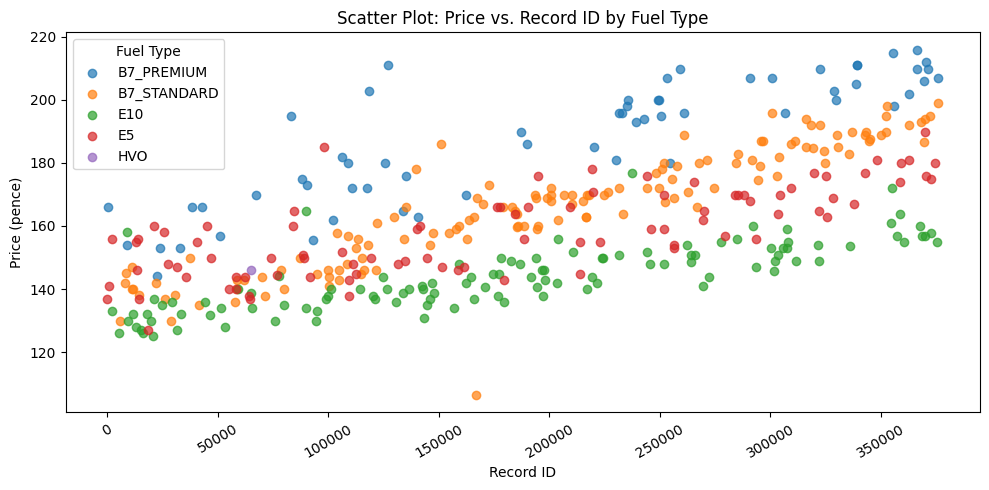

In [ ]:

scatter_sample = df.sample(min(len(df), 400), random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
for fuel in sorted(scatter_sample['fuel_type'].unique()):
    subset = scatter_sample[scatter_sample['fuel_type'] == fuel]
    ax.scatter(subset['id'], subset['price_pence'], label=fuel, alpha=0.7)

ax.set_title('Scatter Plot: Price vs. Record ID by Fuel Type')
ax.set_xlabel('Record ID')
ax.set_ylabel('Price (pence)')
ax.legend(title='Fuel Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Takeaway:** Prices cluster into distinct bands by fuel type. Premium and specialty fuels tend to appear higher on the chart than standard fuels, while most records fall in the mid-range fuel price band.

### Visualization 2 — Line chart

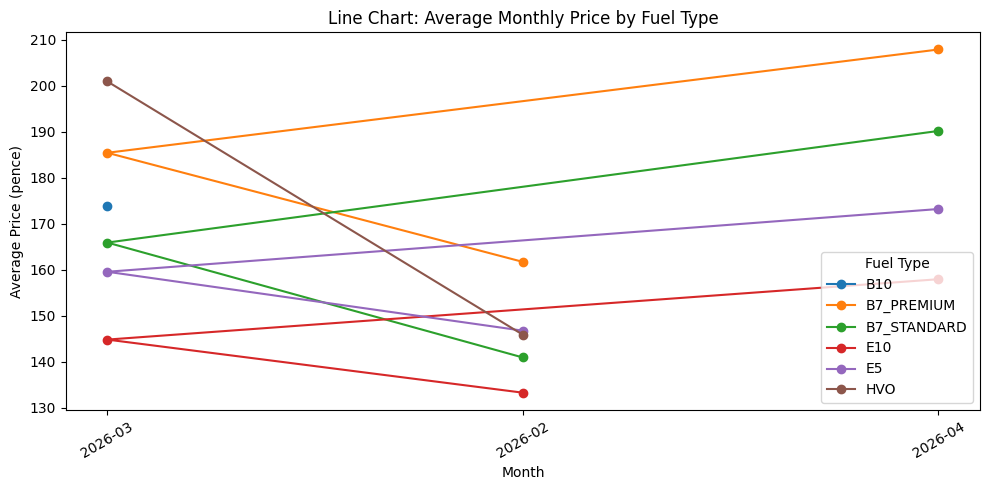

In [ ]:

monthly_fuel_trend = (
    df.groupby(['recorded_month', 'fuel_type'], as_index=False)['price_pence']
      .mean()
      .sort_values(['recorded_month', 'fuel_type'])
)

fig, ax = plt.subplots(figsize=(10, 5))
for fuel in sorted(monthly_fuel_trend['fuel_type'].unique()):
    subset = monthly_fuel_trend[monthly_fuel_trend['fuel_type'] == fuel]
    ax.plot(subset['recorded_month'], subset['price_pence'], marker='o', label=fuel)

ax.set_title('Line Chart: Average Monthly Price by Fuel Type')
ax.set_xlabel('Month')
ax.set_ylabel('Average Price (pence)')
ax.legend(title='Fuel Type')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Takeaway:** The monthly trend makes it easy to compare how each fuel type moved over time. The relative ordering of fuel types stays fairly consistent, with premium or specialty fuels generally priced above standard fuels.

### Visualization 3 — Box plot

/tmp/ipykernel_2301/2624646435.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=fuel_order)


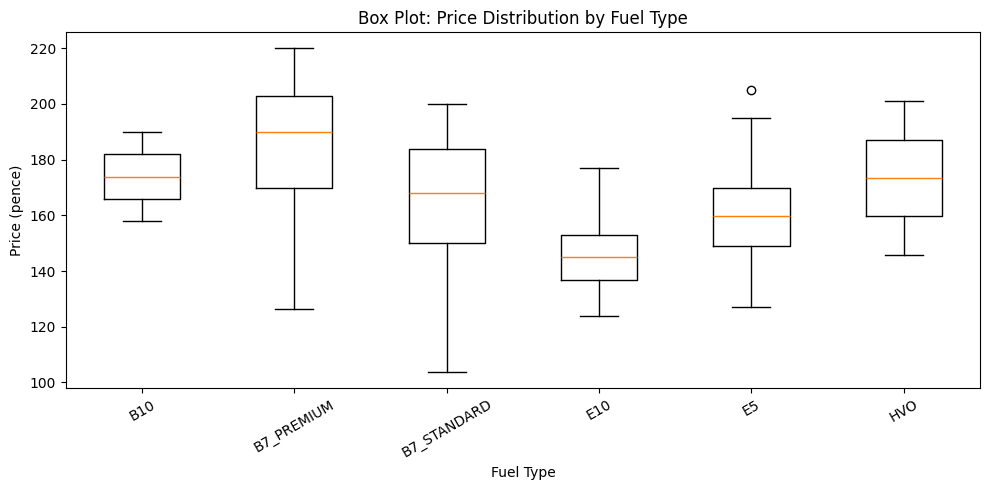

In [ ]:

fuel_order = sorted(df['fuel_type'].unique())
box_data = [df.loc[df['fuel_type'] == fuel, 'price_pence'] for fuel in fuel_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(box_data, labels=fuel_order)
ax.set_title('Box Plot: Price Distribution by Fuel Type')
ax.set_xlabel('Fuel Type')
ax.set_ylabel('Price (pence)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Takeaway:** The box plot shows both the typical price range and the spread for each fuel type. Some fuels have tighter distributions, while others show more variation across stations and dates.

### Visualization 4 — Histogram

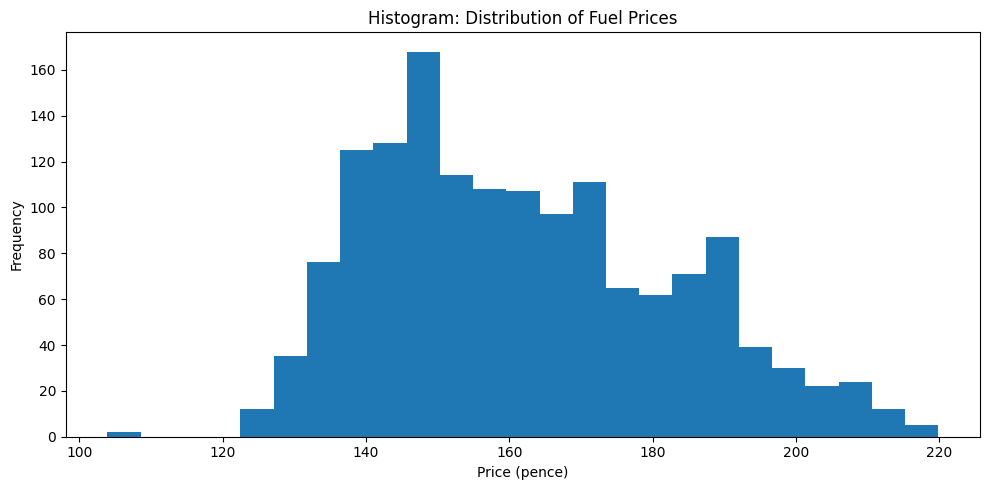

In [ ]:

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['price_pence'], bins=25)
ax.set_title('Histogram: Distribution of Fuel Prices')
ax.set_xlabel('Price (pence)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


**Takeaway:** Most observations are concentrated within a relatively narrow price range, which suggests that the cleaned dataset is dominated by normal everyday fuel prices rather than extreme values.

### Visualization 5 — Heatmap

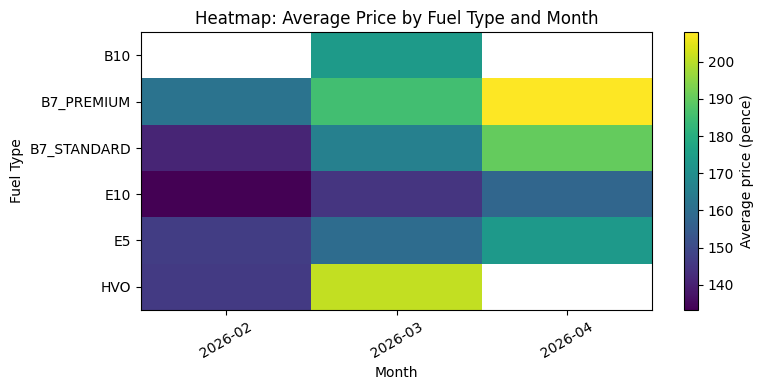

recorded_month,2026-02,2026-03,2026-04
fuel_type,,,
B10,NaN,173.900000,NaN
B7_PREMIUM,161.720588,185.410141,207.838462
B7_STANDARD,140.961039,165.915586,190.153763
E10,133.320270,144.849159,157.958209
E5,146.780357,159.576000,173.200000
HVO,145.900000,200.900000,NaN


In [ ]:

heatmap_data = (
    df.pivot_table(
        index='fuel_type',
        columns='recorded_month',
        values='price_pence',
        aggfunc='mean'
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heatmap_data.values, aspect='auto')
ax.set_title('Heatmap: Average Price by Fuel Type and Month')
ax.set_xlabel('Month')
ax.set_ylabel('Fuel Type')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=30)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
fig.colorbar(im, ax=ax, label='Average price (pence)')
plt.tight_layout()
plt.show()

heatmap_data


**Takeaway:** The heatmap gives a quick comparison across both time and fuel type at once. Darker cells highlight combinations of month and fuel type with higher average prices.